In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import plotly.io as pio

# Asegurar que Plotly se renderice bien en Colab/Jupyter
pio.renderers.default = "colab"

# ==========================================
# 1. PARÁMETROS BIOLÓGICOS (Fase 3: Datos Reales)
# ==========================================
# Basado en la diferencia de fecundidad (50 vs 80 huevos)
# y velocidad de desarrollo de Aedes albopictus.
r_n = 3.91  # Tasa raza Nativa (Foshan)
r_i = 4.38  # Tasa raza Invasora (Tapachula)
N0 = 10     # Población inicial de mosquitos

# ==========================================
# 2. DEFINICIÓN DE MODELOS
# ==========================================
def malthus_continuo(N0, r, t):
    """Ecuación exacta: X(t) = X0 * e^(rt)"""
    return N0 * np.exp(r * t)

def logistico_continuo(N0, r, K, t):
    """Implementación de la solución exacta: X(t) = K / (1 + ((K - N0) / N0) * e^(-rt))"""
    return K / (1 + ((K - N0) / N0) * np.exp(-r * t))

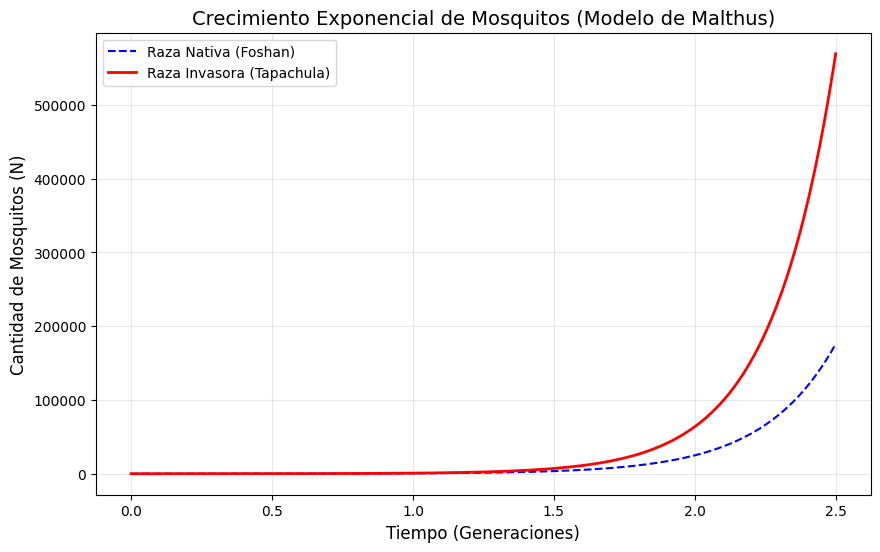

In [2]:
# ==========================================
# VISUALIZACIÓN 1: MODELO DE MALTHUS CONTINUO
# ==========================================
t_malthus = np.linspace(0, 2.5, 300) # Tiempo en generaciones

# Cálculo de las poblaciones
p_nativa_m = malthus_continuo(N0, r_n, t_malthus)
p_invasora_m = malthus_continuo(N0, r_i, t_malthus)

plt.figure(figsize=(10, 6))

# Graficamos con escala normal para ver la curva exponencial
plt.plot(t_malthus, p_nativa_m, label='Raza Nativa (Foshan)', color='blue', linestyle='--')
plt.plot(t_malthus, p_invasora_m, label='Raza Invasora (Tapachula)', color='red', linewidth=2)

plt.title('Crecimiento Exponencial de Mosquitos (Modelo de Malthus)', fontsize=14)
plt.xlabel('Tiempo (Generaciones)', fontsize=12)
plt.ylabel('Cantidad de Mosquitos (N)', fontsize=12)

plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

--- Configuración del Modelo Logístico ---
Defina la población tope (Capacidad de carga K): 100


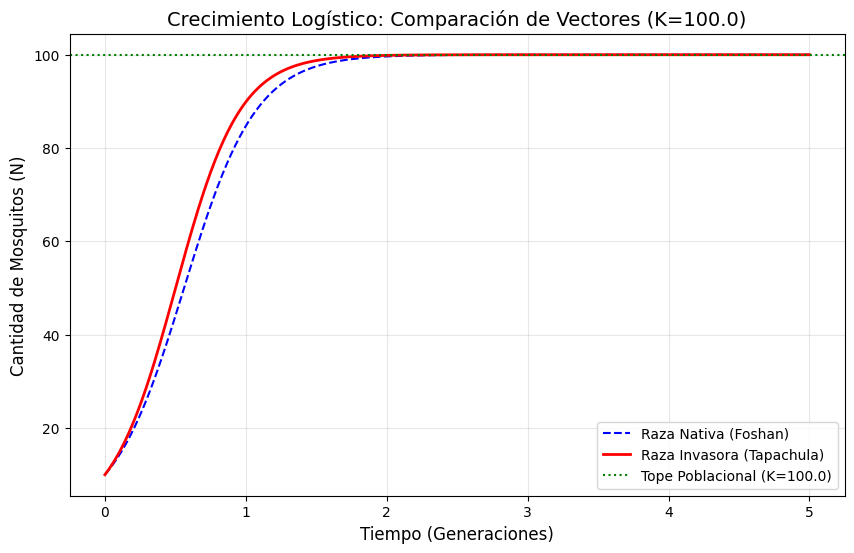

In [3]:
# ==========================================
# VISUALIZACIÓN 2: MODELO LOGÍSTICO (Input)
# ==========================================
try:
    print("--- Configuración del Modelo Logístico ---")
    K_input_log = float(input("Defina la población tope (Capacidad de carga K): "))
except ValueError:
    print("Entrada no válida. Usando valor predeterminado K = 5000")
    K_input_log = 5000.0

t_log = np.linspace(0, 5, 500)

# Cálculo de las poblaciones
p_nativa_l = logistico_continuo(N0, r_n, K_input_log, t_log)
p_invasora_l = logistico_continuo(N0, r_i, K_input_log, t_log)

plt.figure(figsize=(10, 6))

plt.plot(t_log, p_nativa_l, label='Raza Nativa (Foshan)', color='blue', linestyle='--')
plt.plot(t_log, p_invasora_l, label='Raza Invasora (Tapachula)', color='red', linewidth=2)
plt.axhline(y=K_input_log, color='green', linestyle=':', label=f'Tope Poblacional (K={K_input_log})')

plt.title(f'Crecimiento Logístico: Comparación de Vectores (K={K_input_log})', fontsize=14)
plt.xlabel('Tiempo (Generaciones)', fontsize=12)
plt.ylabel('Cantidad de Mosquitos (N)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend(loc='lower right')
plt.show()

--- Configuración de la Simulación (IWG-400) ---
Defina la población tope (K o L): 10000
Defina el rango de tiempo (Generaciones): 20


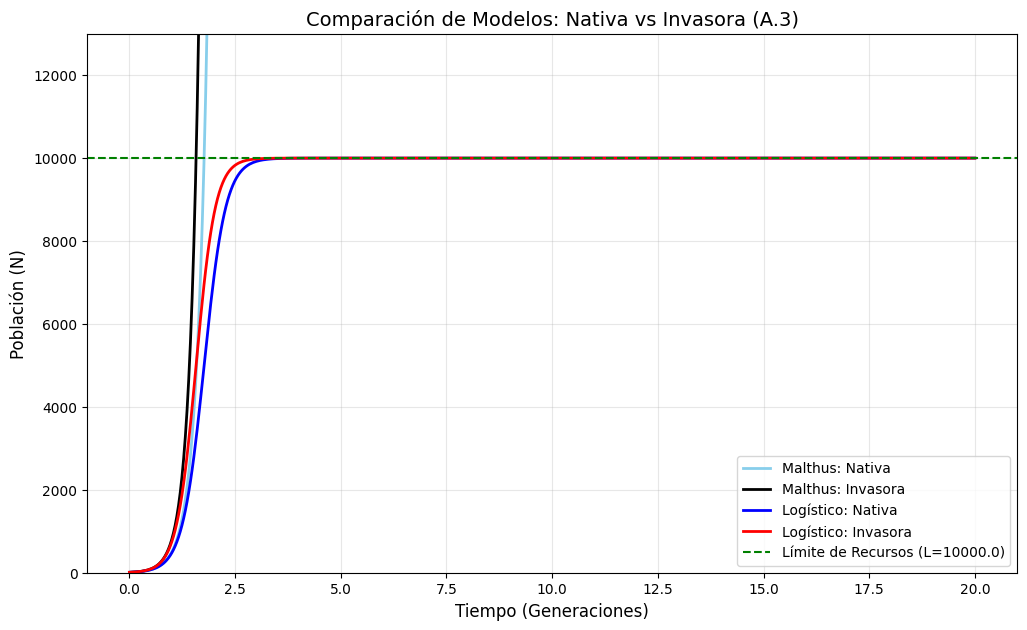

In [4]:
# ==========================================
# VISUALIZACIÓN 3: COMPARACIÓN DE MODELOS (Matplotlib)
# ==========================================
try:
    print("--- Configuración de la Simulación (IWG-400) ---")
    K_input_comp = float(input("Defina la población tope (K o L): "))
    t_max_comp = float(input("Defina el rango de tiempo (Generaciones): "))
except ValueError:
    print("Entrada no válida. Usando valores predeterminados: K=5000, t=2.2")
    K_input_comp = 5000.0
    t_max_comp = 2.2

t_comp = np.linspace(0, t_max_comp, 500)

# Cálculo de las 4 trayectorias
m_nat = malthus_continuo(N0, r_n, t_comp)
m_inv = malthus_continuo(N0, r_i, t_comp)
l_nat = logistico_continuo(N0, r_n, K_input_comp, t_comp)
l_inv = logistico_continuo(N0, r_i, K_input_comp, t_comp)

plt.figure(figsize=(12, 7))

# Curvas
plt.plot(t_comp, m_nat, label='Malthus: Nativa', color='skyblue', linewidth=2)
plt.plot(t_comp, m_inv, label='Malthus: Invasora', color='black', linewidth=2)
plt.plot(t_comp, l_nat, label='Logístico: Nativa', color='blue', linewidth=2)
plt.plot(t_comp, l_inv, label='Logístico: Invasora', color='red', linewidth=2)
plt.axhline(y=K_input_comp, color='green', linestyle='--', label=f'Límite de Recursos (L={K_input_comp})')

plt.title('Comparación de Modelos: Nativa vs Invasora (A.3)', fontsize=14)
plt.xlabel('Tiempo (Generaciones)', fontsize=12)
plt.ylabel('Población (N)', fontsize=12)
plt.ylim(0, K_input_comp * 1.3)
plt.grid(True, alpha=0.3)
plt.legend(loc='lower right', fontsize=10)
plt.show()

In [5]:
# ==========================================
# VISUALIZACIÓN 4: GRÁFICO INTERACTIVO (PLOTLY)
# ==========================================
# Utilizamos las variables calculadas en la Celda 4 (t_comp, m_nat, m_inv, l_nat, l_inv, K_input_comp, t_max_comp)
# Si deseas que esta celda funcione de manera independiente, deberás agregar los inputs aquí nuevamente.

fig = go.Figure()

# Modelo de Malthus
fig.add_trace(go.Scatter(x=t_comp, y=m_nat, mode='lines', name='Malthus: Nativa',
                         line=dict(color='skyblue', width=3)))
fig.add_trace(go.Scatter(x=t_comp, y=m_inv, mode='lines', name='Malthus: Invasora',
                         line=dict(color='black', width=3)))

# Modelo Logístico
fig.add_trace(go.Scatter(x=t_comp, y=l_nat, mode='lines', name='Logístico: Nativa',
                         line=dict(color='blue', width=3)))
fig.add_trace(go.Scatter(x=t_comp, y=l_inv, mode='lines', name='Logístico: Invasora',
                         line=dict(color='red', width=3)))

# Línea de Capacidad de Carga
fig.add_trace(go.Scatter(x=[0, t_max_comp], y=[K_input_comp, K_input_comp], mode='lines',
                         name=f'Límite L={K_input_comp}',
                         line=dict(color='green', width=2, dash='dash')))

# Configuración del diseño
fig.update_layout(
    title='Dinámica Poblacional Interactiva: Aedes albopictus (A.3)',
    xaxis_title='Tiempo (Generaciones)',
    yaxis_title='Población (N)',
    yaxis=dict(range=[0, K_input_comp * 1.3]),
    legend=dict(yanchor="bottom", y=0.01, xanchor="right", x=0.99),
    hovermode="x unified",
    template="plotly_white"
)

fig.show()